In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.datasets import make_blobs, make_moons
from sklearn.cluster import AgglomerativeClustering
from hierarchical_clustering import hierarchical_clustering

### 1 Test poprawności algorytmu hierarchical_clustering

Wygenerujmy przykładowy zbiór punktów i sprawdźmy czy funkcja hierarchical_clustering() poprawnie wyznacza skupienia i ich liczbę

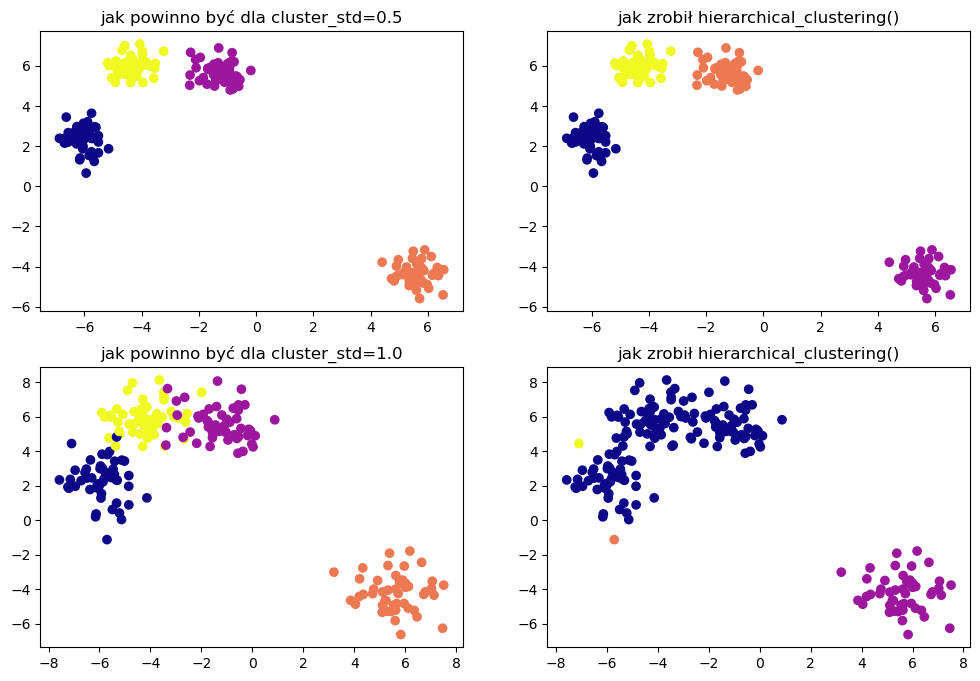

In [2]:
X1, y1 = make_blobs(200, centers=4, cluster_std=0.5, random_state=1234)
X2, y2 = make_blobs(200, centers=4, cluster_std=1.0, random_state=1234)

df1 = pd.DataFrame(X1, columns=["X1", "X2"])
df1.insert(0, "y", y1)
df2 = pd.DataFrame(X2, columns=["X1", "X2"])
df2.insert(0, "y", y2)

fig, axs = plt.subplots(2,2)
fig.set_size_inches(12,8)
axs[0, 0].scatter(X1[:, 0], X1[:, 1], c=df1["y"], cmap="plasma")
axs[0, 0].set_title("jak powinno być dla cluster_std=0.5")
axs[0, 1].scatter(X1[:, 0], X1[:, 1], c=hierarchical_clustering(X1, n_clusters=4), cmap="plasma")
axs[0, 1].set_title("jak zrobił hierarchical_clustering()")
axs[1, 0].scatter(X2[:, 0], X2[:, 1], c=df2["y"], cmap="plasma")
axs[1, 0].set_title("jak powinno być dla cluster_std=1.0")
axs[1, 1].scatter(X2[:, 0], X2[:, 1], c=hierarchical_clustering(X2, n_clusters=4), cmap="plasma")
axs[1, 1].set_title("jak zrobił hierarchical_clustering()")
plt.show()

Zatem widać, że funkcja działa, ale tylko dla odpowiednio oddalonych od siebie skupisk. Jeżeli zwiększymy parametr cluster_std, to wówczas 
skupiska będą szersze,a co za tym idzie bardzo możliwe, że będą nachodzić na siebie i funkcja hierarchical_clustering() będzie łapać punkty
z jedego skupiska i przyporządkowywać je do innego. Warto zauważyć, że AgglomerativeClustering również nie radzi sobie z nachodzącymi skupiskami.

### 2.1 Zbiór danych

Eksperymentowy zbiór danych powstał poprzez  dwóch rodzajów skupisk. Pierwsze z nich kuliste zawiera 3 skupiska, drugie natomiast księżycowe
zawiera 2 skupiska. Łącznie jest ich 5. Są one odpowiednio sformatowane. Kuliste przetransformowane na eliptyczne, a wszytskie skupiska zostały ułożone tak, aby były wystarczająco od siebie oddalon, ponieważ inaczej algorytmy wykrzaczałyby się przy nachodzących na siebie skupiskach. Sprawdzić mamy bowiem czy hierarchical_clustering() czyta różne ilości skupisk i je same identycznie jak AgglomerativeClustering.

In [ ]:
X_b, y_b = make_blobs(n_samples=300, centers=[[-10, 10], [5, 12], [10, -10]], cluster_std=2, random_state=1234)
transformation = [[1.4, -0.8], [-0.3, 1.3]]
X_b = np.dot(X_b, transformation)

X_m, y_m = make_moons(n_samples=200, noise=0.15, random_state=1234)
X_m = X_m*7
X_m[y_m == 1] += [0, -12]
X_m += [-12, -10]
y_m += 3

X = np.vstack([X_b, X_m])
y = np.concatenate([y_b, y_m])

df = pd.DataFrame(X, columns=["X1", "X2"])
df.insert(0, "y", y)

#df.to_csv("333063_data.csv", index=False)

plt.figure(figsize=(8, 5))
plt.scatter(df["X1"], df["X2"], c=df["y"], alpha=0.9, edgecolors="none")
plt.title("Zbiór danych do testowania algorytmu")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

PermissionError: [Errno 13] Permission denied: '333063_data.csv'

### 2.2 Eksperyment

Dla kilku różnych wartości parametru n_clusters przeprowadzony zostanie eksperyment porównujący, czy hierarchical_clustering() czyta skupiska identycznie jak AgglomerativeClustering. Wyniki zostaną przedstawione w postaci wykresów.

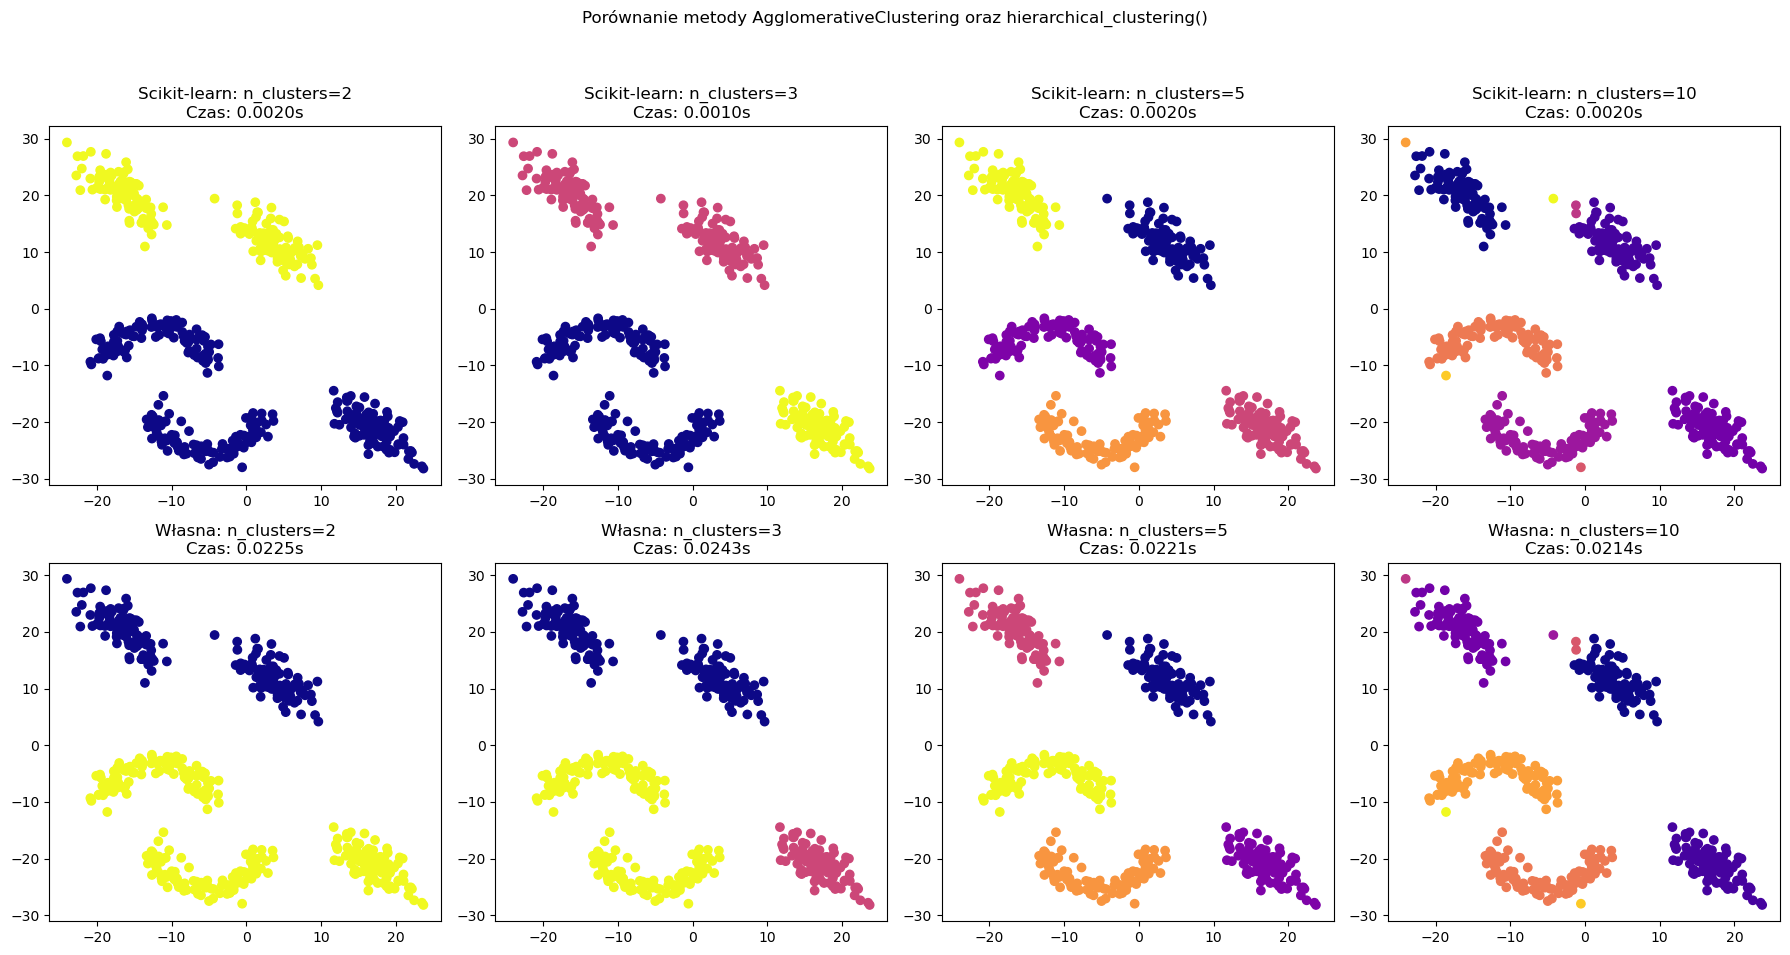

In [85]:
fig, axs = plt.subplots(2,4)
fig.set_size_inches(18,10)
fig.suptitle("Porównanie metody AgglomerativeClustering oraz hierarchical_clustering()")

n_clusters_values = [2,3,5,10]
for i, val in enumerate(n_clusters_values):
    start_agc = time.time()
    agc = AgglomerativeClustering(linkage="single", n_clusters=val).fit(X)
    time_agc = time.time() - start_agc
    axs[0, i].scatter(X[:, 0], X[:, 1], c=agc.labels_, cmap="plasma")
    axs[0, i].set_title(f"Scikit-learn: n_clusters={val}\nCzas: {time_agc:.4f}s")
    
    start_own = time.time()
    own_labels = hierarchical_clustering(X, n_clusters=val)
    time_own = time.time() - start_own
    axs[1, i].scatter(X[:, 0], X[:, 1], c=own_labels, cmap="plasma")
    axs[1, i].set_title(f"Własna: n_clusters={val}\nCzas: {time_own:.4f}s")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Na powyższych wykresach widać bardzo dokładnie, że obie metody identycznie identyfikują skupienia dla różnych wartości parametru n_clusters i robią to idealnie. Można także zauważyć, że dla zbioru eksperymentalnego, którego liczba skupisk jest znana i wynosi 5, algorytm hierarchical_clustering() wyznaczył je wszystkie ze 100% dokładnością.